# Classification Model Benchmark

Compare package QML classifiers against classical classification baselines using the shared benchmark framework. Defaults are intentionally small so the notebook can be run quickly; increase `seeds`, `n_samples`, and training `steps` for stronger benchmark evidence.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve()
if not (repo_root / "src" / "qml").exists():
    repo_root = next(
        (parent for parent in repo_root.parents if (parent / "src" / "qml").exists()),
        repo_root,
    )
package_root = repo_root / "src"
if str(package_root) not in sys.path:
    sys.path.insert(0, str(package_root))

In [2]:
from qml.benchmarks import compare_classification_models
from qml.reporting import print_table
import matplotlib.pyplot as plt

## Benchmark Configuration

In [3]:
CONFIG = {
    "dataset": "moons",
    "seeds": [0],
    "n_samples": 32,
    "noise": 0.12,
    "test_size": 0.25,
    "tune_classical": False,
    "cv": 3,
}

models = [
    "vqc",
    "qcnn",
    "quantum_kernel",
    "quantum_reservoir",
    "logistic_regression",
    "svm_classifier",
    "random_forest_classifier",
]

model_kwargs = {
    "vqc": {"n_layers": 1, "steps": 4, "step_size": 0.1},
    "qcnn": {"steps": 4, "step_size": 0.1},
    "quantum_reservoir": {"n_layers": 1},
    "random_forest_classifier": {"n_estimators": 20},
}

In [4]:
def summary_rows(result, metric):
    rows = []
    for model, stats in result["summary"].items():
        metric_stats = stats[metric]
        gap_stats = stats["generalization_gap"]
        runtime_stats = stats["runtime_seconds"]
        rows.append(
            {
                "model": model,
                metric: metric_stats["mean"],
                "ci95_low": metric_stats["ci95_low"],
                "ci95_high": metric_stats["ci95_high"],
                "gap": gap_stats["mean"],
                "runtime_s": runtime_stats["mean"],
                "runs": stats["n_runs"],
            }
        )
    return sorted(rows, key=lambda row: row[metric], reverse=True)


def paired_rows(result):
    comparison = result["paired_vs_best_classical"]
    rows = []
    for model, stats in comparison["comparisons"].items():
        rows.append(
            {
                "model": model,
                "mean_delta": stats["mean_delta"]["mean"],
                "wins": stats["wins"],
                "losses": stats["losses"],
                "ties": stats["ties"],
                "pairs": stats["n_pairs"],
            }
        )
    return rows

## Full Classifier Comparison

In [5]:
classification_benchmark = compare_classification_models(
    models=models,
    seeds=CONFIG["seeds"],
    n_samples=CONFIG["n_samples"],
    noise=CONFIG["noise"],
    test_size=CONFIG["test_size"],
    dataset=CONFIG["dataset"],
    tune_classical=CONFIG["tune_classical"],
    cv=CONFIG["cv"],
    model_kwargs=model_kwargs,
    save=False,
)

print_table(summary_rows(classification_benchmark, "test_accuracy"), title="Classification summary")
print_table(paired_rows(classification_benchmark), title=f"Paired deltas vs {classification_benchmark['paired_vs_best_classical']['reference_model']}")
print_table(classification_benchmark["best_model"], title="Best model")

Classification summary
+--------------------------+---------------+----------+-----------+----------+------------+------+
| model                    | test_accuracy | ci95_low | ci95_high | gap      | runtime_s  | runs |
+--------------------------+---------------+----------+-----------+----------+------------+------+
| qcnn                     | 0.75          | 0.75     | 0.75      | 0.125    | 5.62908    | 1    |
| quantum_kernel           | 0.75          | 0.75     | 0.75      | 0.166667 | 0.803903   | 1    |
| logistic_regression      | 0.75          | 0.75     | 0.75      | 0.166667 | 0.00547163 | 1    |
| svm_classifier           | 0.75          | 0.75     | 0.75      | 0.166667 | 0.00400665 | 1    |
| random_forest_classifier | 0.75          | 0.75     | 0.75      | 0.25     | 0.0407517  | 1    |
| vqc                      | 0.625         | 0.625    | 0.625     | 0        | 0.947511   | 1    |
| quantum_reservoir        | 0.5           | 0.5      | 0.5       | 0.125    | 0.10972

## Summary Plots

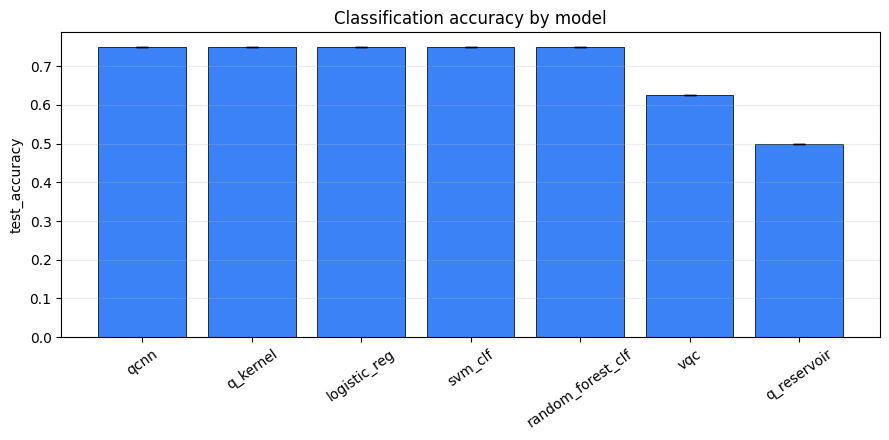

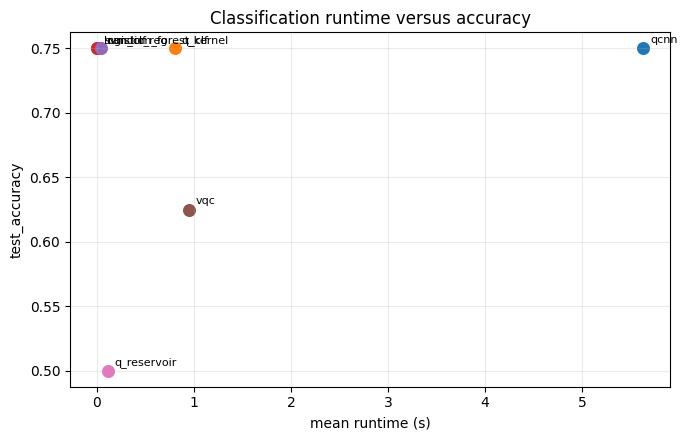

In [6]:

import matplotlib.pyplot as plt


def _short_label(label):
    return label.replace("quantum_", "q_").replace("_regression", "_reg").replace("_classifier", "_clf")


def plot_metric_bars(rows, metric, title, *, lower_is_better=False):
    ordered = sorted(rows, key=lambda row: row[metric], reverse=not lower_is_better)
    labels = [_short_label(row["model"]) for row in ordered]
    values = [row[metric] for row in ordered]
    errors = [
        [max(0.0, row[metric] - row.get("ci95_low", row[metric])) for row in ordered],
        [max(0.0, row.get("ci95_high", row[metric]) - row[metric]) for row in ordered],
    ]
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.bar(labels, values, yerr=errors, capsize=4, color="#3b82f6", edgecolor="#1f2937", linewidth=0.7)
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=35)
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    plt.show()


def plot_runtime_scatter(rows, metric, title, *, lower_is_better=False):
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for row in rows:
        ax.scatter(row["runtime_s"], row[metric], s=70)
        ax.annotate(_short_label(row["model"]), (row["runtime_s"], row[metric]), xytext=(5, 4), textcoords="offset points", fontsize=8)
    ax.set_title(title)
    ax.set_xlabel("mean runtime (s)")
    ax.set_ylabel(metric)
    if lower_is_better:
        ax.invert_yaxis()
    ax.grid(alpha=0.25)
    fig.tight_layout()
    plt.show()


def plot_dataset_bars(rows, metric, title, *, lower_is_better=False):
    datasets = list(dict.fromkeys(row["dataset"] for row in rows))
    models = list(dict.fromkeys(row["model"] for row in rows))
    width = 0.8 / max(1, len(models))
    x = list(range(len(datasets)))
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for index, model in enumerate(models):
        values = []
        for dataset in datasets:
            match = next((row for row in rows if row["dataset"] == dataset and row["model"] == model), None)
            values.append(float("nan") if match is None else match[metric])
        offsets = [position - 0.4 + width / 2 + index * width for position in x]
        ax.bar(offsets, values, width=width, label=_short_label(model))
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.set_xticks(x, datasets)
    if lower_is_better:
        ax.invert_yaxis()
    ax.grid(axis="y", alpha=0.25)
    ax.legend(fontsize=8, ncols=2)
    fig.tight_layout()
    plt.show()

summary = summary_rows(classification_benchmark, "test_accuracy")
plot_metric_bars(summary, "test_accuracy", "Classification accuracy by model")
plot_runtime_scatter(summary, "test_accuracy", "Classification runtime versus accuracy")

## Dataset Sweep

This sweep uses a smaller model set that is valid across all supported binary classification datasets.

In [7]:
sweep_models = ["vqc", "quantum_kernel", "quantum_reservoir", "svm_classifier"]
sweep_datasets = ["moons", "circles", "wine"]

sweep_rows = []
for dataset in sweep_datasets:
    result = compare_classification_models(
        models=sweep_models,
        seeds=CONFIG["seeds"],
        n_samples=CONFIG["n_samples"],
        noise=CONFIG["noise"],
        test_size=CONFIG["test_size"],
        dataset=dataset,
        model_kwargs={"vqc": model_kwargs["vqc"], "quantum_reservoir": {"n_layers": 1}},
        save=False,
    )
    for row in summary_rows(result, "test_accuracy"):
        sweep_rows.append({"dataset": dataset, **row})

print_table(sweep_rows, title="Classification dataset sweep")

Classification dataset sweep
+---------+-------------------+---------------+----------+-----------+------------+------------+------+
| dataset | model             | test_accuracy | ci95_low | ci95_high | gap        | runtime_s  | runs |
+---------+-------------------+---------------+----------+-----------+------------+------------+------+
| moons   | quantum_kernel    | 0.75          | 0.75     | 0.75      | 0.166667   | 0.824642   | 1    |
| moons   | svm_classifier    | 0.75          | 0.75     | 0.75      | 0.166667   | 0.00476372 | 1    |
| moons   | vqc               | 0.625         | 0.625    | 0.625     | 0          | 0.729732   | 1    |
| moons   | quantum_reservoir | 0.5           | 0.5      | 0.5       | 0.125      | 0.203644   | 1    |
| circles | quantum_kernel    | 0.875         | 0.875    | 0.875     | 0.125      | 0.799363   | 1    |
| circles | svm_classifier    | 0.875         | 0.875    | 0.875     | 0.125      | 0.00514769 | 1    |
| circles | vqc               | 0.5

## Dataset Sweep Plot

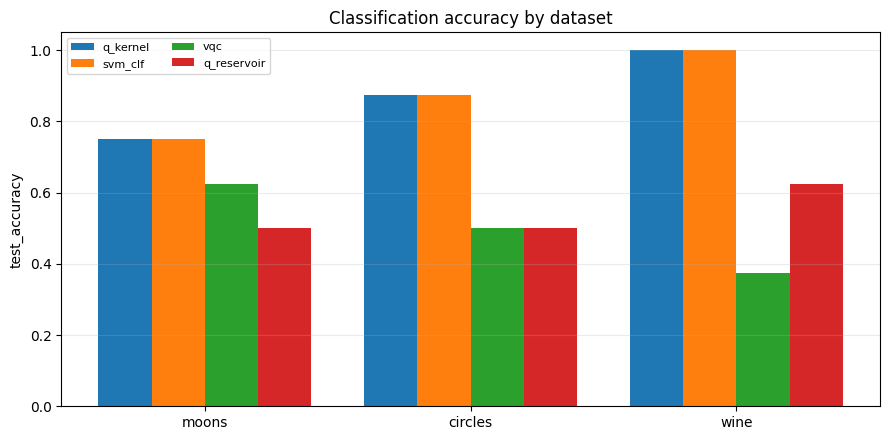

In [8]:
plot_dataset_bars(sweep_rows, "test_accuracy", "Classification accuracy by dataset")